# RBI Repo Rate Forecasting Model
## Monthly compact policy model: Logit + Ridge, Random Forest and 50:50 Ensemble

**Objective:** Forecast the cumulative RBI repo-rate change over the next **1, 2, 3 and 6 months** as:
- **Cut**
- **Hold**
- **Hike**

The notebook follows the same monthly pipeline used for the Fed model:
1. Compact macro-financial feature set.
2. All predictors lagged one month.
3. Expanding-window backtest.
4. Multinomial Logit + Ridge benchmark.
5. Conservative Random Forest robustness model.
6. Equal-weight ensemble forecast.

**Required local files**
- `SCB_India.xlsx` with sheets: `Repo`, `CRR`, `Bank_rate`.
- `CPI.xlsx` with columns: `Month`, `CPI`.


In [1]:
# ============================================================
# 0. IMPORTS AND SETTINGS
# ============================================================

import os
import io
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    log_loss,
    brier_score_loss
)

pd.set_option("display.max_columns", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

SCB_PATH = "SCB_India.xlsx"
CPI_PATH = "CPI.xlsx"

START = "2000-01-01"
END = pd.Timestamp.today().strftime("%Y-%m-%d")

DATA_DIR = "rbi_repo_policy_data"
os.makedirs(DATA_DIR, exist_ok=True)

# Standard RBI move is normally 25 bp.
MOVE_STEP_BP = 25

# The forecast horizons used in the Fed model.
HORIZONS = [1, 2, 3, 6]

# Training history required before the first expanding forecast.
MIN_TRAIN_MONTHS = 120

# Equal weights: transparent and robust for a modest sample.
W_LOGIT = 0.50
W_RF = 0.50

POLICY_CLASSES = np.array(["Cut", "Hold", "Hike"])

print("Notebook settings loaded.")


Notebook settings loaded.


## 1. Load RBI policy and CPI data

In [2]:
# ============================================================
# 1. HELPER FUNCTIONS: MONTH-END STANDARDISATION
# ============================================================

def to_month_end(series):
    """Convert any date series to a common calendar month-end index."""
    return (
        pd.to_datetime(series, errors="coerce")
        .dt.to_period("M")
        .dt.to_timestamp("M")
    )

def read_monthly_excel_series(file_path, sheet_name, date_col, value_col, output_col):
    """
    Read an RBI / policy series from Excel and convert it to month-end.
    Works with monthly or irregular decision-date input:
    the last value observed in each month is retained.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Missing required file: {file_path}\n"
            "Place the Excel file in the same folder as this notebook "
            "or update the file path in Cell 0."
        )

    raw = pd.read_excel(file_path, sheet_name=sheet_name)

    if date_col not in raw.columns or value_col not in raw.columns:
        raise ValueError(
            f"Sheet '{sheet_name}' must contain columns "
            f"'{date_col}' and '{value_col}'."
        )

    out = raw[[date_col, value_col]].copy()
    out.columns = ["Month", output_col]

    out["Month"] = to_month_end(out["Month"])
    out[output_col] = pd.to_numeric(out[output_col], errors="coerce")

    out = (
        out.dropna(subset=["Month", output_col])
           .sort_values("Month")
           .groupby("Month", as_index=False)[output_col]
           .last()
    )

    return out

def expand_to_monthly(df, value_col, start=None, end=None):
    """
    Create a complete monthly month-end series and forward-fill policy variables.
    This is appropriate for Repo, CRR and Bank Rate because they stay in force
    until the next policy action.
    """
    out = df.copy().sort_values("Month").set_index("Month")

    start = pd.Timestamp(start).to_period("M").to_timestamp("M") if start else out.index.min()
    end = pd.Timestamp(end).to_period("M").to_timestamp("M") if end else out.index.max()

    full_idx = pd.date_range(start, end, freq="ME")

    out = out.reindex(full_idx).ffill()
    out.index.name = "Month"

    return out.reset_index()


In [3]:
# ============================================================
# 2. LOAD REPO, CRR AND BANK RATE
# ============================================================

repo_raw = read_monthly_excel_series(
    SCB_PATH, "Repo", "Month", "Repo_rate", "Repo_rate"
)

crr_raw = read_monthly_excel_series(
    SCB_PATH, "CRR", "Month", "CRR", "CRR"
)

bank_raw = read_monthly_excel_series(
    SCB_PATH, "Bank_rate", "Month", "Bank_rate", "Bank_rate"
)

repo = expand_to_monthly(repo_raw, "Repo_rate")
crr = expand_to_monthly(
    crr_raw, "CRR",
    start=repo["Month"].min(),
    end=repo["Month"].max()
)
bank_rate = expand_to_monthly(
    bank_raw, "Bank_rate",
    start=repo["Month"].min(),
    end=repo["Month"].max()
)

for name, d, col in [
    ("Repo", repo, "Repo_rate"),
    ("CRR", crr, "CRR"),
    ("Bank Rate", bank_rate, "Bank_rate")
]:
    print(
        f"{name:10s}: {d['Month'].min().date()} to "
        f"{d['Month'].max().date()} | {d[col].notna().sum():,} observations"
    )

display(repo.tail())


Repo      : 2001-04-30 to 2026-06-30 | 303 observations
CRR       : 2001-04-30 to 2026-06-30 | 303 observations
Bank Rate : 2001-04-30 to 2026-06-30 | 303 observations


,Month,Repo_rate
298,2026-02-28,5.250
299,2026-03-31,5.250
300,2026-04-30,5.250
301,2026-05-31,5.250
302,2026-06-30,5.250


In [4]:
# ============================================================
# 3. LOAD CPI AND CREATE CPI INFLATION
# ============================================================

if not os.path.exists(CPI_PATH):
    raise FileNotFoundError(
        f"Missing required file: {CPI_PATH}\n"
        "The file must contain columns: Month and CPI."
    )

cpi_raw = pd.read_excel(CPI_PATH)

required_cpi_cols = {"Month", "CPI"}
if not required_cpi_cols.issubset(cpi_raw.columns):
    raise ValueError(
        "CPI.xlsx must contain exactly these required columns: Month, CPI."
    )

cpi_raw = cpi_raw[["Month", "CPI"]].copy()
cpi_raw["Month"] = to_month_end(cpi_raw["Month"])
cpi_raw["CPI"] = pd.to_numeric(cpi_raw["CPI"], errors="coerce")

cpi_raw = (
    cpi_raw.dropna(subset=["Month", "CPI"])
           .sort_values("Month")
           .groupby("Month", as_index=False)["CPI"]
           .last()
)

cpi_raw["CPI_Inflation_YoY"] = cpi_raw["CPI"].pct_change(12) * 100

cpi = cpi_raw[["Month", "CPI_Inflation_YoY"]].copy()

print(
    f"CPI index: {cpi_raw['Month'].min().date()} to "
    f"{cpi_raw['Month'].max().date()} | {len(cpi_raw):,} observations"
)

display(cpi.tail())


CPI index: 2013-01-31 to 2026-05-31 | 161 observations


,Month,CPI_Inflation_YoY
156,2026-01-31,2.734
157,2026-02-28,3.208
158,2026-03-31,3.403
159,2026-04-30,3.485
160,2026-05-31,3.935


## 2. Download global and market variables

In [5]:
# ============================================================
# 4. FRED: MONTHLY EFFECTIVE FED FUNDS RATE
# No FRED API key required.
# ============================================================

def get_fred_monthly(series_id, output_col):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

    try:
        raw = pd.read_csv(url)

        date_col = next(
            c for c in ["observation_date", "DATE", "Date", "date"]
            if c in raw.columns
        )
        value_col = next(c for c in raw.columns if c != date_col)

        out = raw[[date_col, value_col]].copy()
        out.columns = ["Month", output_col]

        out["Month"] = to_month_end(out["Month"])
        out[output_col] = pd.to_numeric(out[output_col], errors="coerce")

        out = (
            out.dropna(subset=["Month", output_col])
               .sort_values("Month")
               .groupby("Month", as_index=False)[output_col]
               .last()
        )

        return out

    except Exception as e:
        print(f"FRED download failed for {series_id}: {e}")
        return pd.DataFrame(columns=["Month", output_col])

fed_funds = get_fred_monthly("FEDFUNDS", "Fed_Funds")

if fed_funds.empty:
    raise RuntimeError(
        "Fed Funds data could not be downloaded. "
        "Check internet access and rerun this cell."
    )

print(
    f"Fed funds: {fed_funds['Month'].min().date()} to "
    f"{fed_funds['Month'].max().date()} | {len(fed_funds):,} observations"
)

display(fed_funds.tail())


Fed funds: 1954-07-31 to 2026-05-31 | 863 observations


,Month,Fed_Funds
858,2026-01-31,3.640
859,2026-02-28,3.640
860,2026-03-31,3.640
861,2026-04-30,3.640
862,2026-05-31,3.630


In [6]:
# ============================================================
# 5. YAHOO FINANCE: BRENT, USD/INR, INDIA VIX, NIFTY 50
# ============================================================

def fetch_yf_monthly(ticker, output_col, start=START):
    """
    Download adjusted close and standardise to calendar month-end.
    """
    raw = yf.download(
        ticker,
        start=start,
        end=END,
        interval="1mo",
        auto_adjust=True,
        progress=False,
        threads=False
    )

    if raw.empty:
        raise ValueError(f"No yfinance data returned for {ticker}.")

    close = raw["Close"].copy()

    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]

    out = close.to_frame(name=output_col).reset_index()
    out.columns = ["Month", output_col]

    out["Month"] = to_month_end(out["Month"])
    out[output_col] = pd.to_numeric(out[output_col], errors="coerce")

    out = (
        out.dropna(subset=["Month", output_col])
           .sort_values("Month")
           .groupby("Month", as_index=False)[output_col]
           .last()
    )

    return out

market_specs = {
    "Brent_USD": ("BZ=F", "Brent_USD"),
    "USDINR": ("INR=X", "USDINR"),
    "India_VIX": ("^INDIAVIX", "India_VIX"),
    "Nifty50": ("^NSEI", "Nifty50")
}

market_data = {}

for name, (ticker, output_col) in market_specs.items():
    print(f"Downloading {name}: {ticker}")
    market_data[name] = fetch_yf_monthly(ticker, output_col)

brent = market_data["Brent_USD"]
usdinr = market_data["USDINR"]
india_vix = market_data["India_VIX"]
nifty = market_data["Nifty50"]

for name, d in market_data.items():
    print(
        f"{name:10s}: {d['Month'].min().date()} to "
        f"{d['Month'].max().date()} | {len(d):,} observations"
    )


Brent_USD : 2007-08-31 to 2026-06-30 | 194 observations
USDINR    : 2003-12-31 to 2026-06-30 | 271 observations
India_VIX : 2008-03-31 to 2026-06-30 | 220 observations
Nifty50   : 2007-09-30 to 2026-06-30 | 226 observations


## 3. Build the monthly RBI policy panel

In [7]:
# ============================================================
# 6. BUILD CLEAN MONTHLY MASTER PANEL
# No blanket forward-fill across all variables
# ============================================================

panel = repo.copy()

# Policy variables can safely be forward-filled because they
# remain in force until the next RBI action.
for data, col in [
    (crr, "CRR"),
    (bank_rate, "Bank_rate")
]:
    panel = panel.merge(data[["Month", col]], on="Month", how="left")

panel[["CRR", "Bank_rate"]] = panel[
    ["CRR", "Bank_rate"]
].ffill()

# Macro and market variables should NOT be mechanically
# forward-filled across missing historical periods.
for data, col in [
    (cpi, "CPI_Inflation_YoY"),
    (brent, "Brent_USD"),
    (usdinr, "USDINR"),
    (india_vix, "India_VIX"),
    (fed_funds, "Fed_Funds"),
    (nifty, "Nifty50")
]:
    panel = panel.merge(data[["Month", col]], on="Month", how="left")

panel = panel.sort_values("Month").reset_index(drop=True)

print("Raw panel:")
display(
    panel.isna().sum()
    .to_frame("Missing observations")
    .assign(
        Missing_pct=lambda x: (
            100 * x["Missing observations"] / len(panel)
        ).round(1)
    )
)

Raw panel:


,Missing observations,Missing_pct
Month,0,0.000
Repo_rate,0,0.000
CRR,0,0.000
Bank_rate,0,0.000
CPI_Inflation_YoY,154,50.800
Brent_USD,109,36.000
USDINR,32,10.600
India_VIX,83,27.400
Fed_Funds,1,0.300
Nifty50,77,25.400


In [8]:
# ============================================================
# 6A. RESTRICT TO COMMON, RELIABLE SAMPLE
# ============================================================

required_model_columns = [
    "Repo_rate",
    "CPI_Inflation_YoY",
    "Brent_USD",
    "USDINR",
    "India_VIX",
    "Fed_Funds",
    "Nifty50"
]

panel_clean = (
    panel
    .dropna(subset=required_model_columns)
    .copy()
    .sort_values("Month")
    .reset_index(drop=True)
)

print("Clean model panel shape:", panel_clean.shape)
print(
    "Clean coverage:",
    panel_clean["Month"].min().date(),
    "to",
    panel_clean["Month"].max().date()
)

display(
    panel_clean.isna().sum()
    .to_frame("Missing observations")
    .assign(
        Missing_pct=lambda x: (
            100 * x["Missing observations"] / len(panel_clean)
        ).round(1)
    )
)

Clean model panel shape: (127, 10)
Clean coverage: 2014-01-31 to 2026-05-31


,Missing observations,Missing_pct
Month,0,0.000
Repo_rate,0,0.000
CRR,0,0.000
Bank_rate,0,0.000
CPI_Inflation_YoY,0,0.000
Brent_USD,0,0.000
USDINR,0,0.000
India_VIX,0,0.000
Fed_Funds,0,0.000
Nifty50,0,0.000


## 4. Direct multi-horizon targets and model functions

In [11]:
model_df = panel_clean.copy()

In [12]:
# ============================================================
# 8. CREATE DIRECT HORIZON TARGETS
#
# Uses the cleaned common-sample panel only.
#
# h=1: Repo rate at t+1 minus repo rate at t
# h=2: Repo rate at t+2 minus repo rate at t
# etc.
#
# A target is set to NaN if the required future month is not
# actually consecutive in calendar time.
# ============================================================

def create_policy_targets(
    data,
    horizon_months,
    move_threshold_bp=5,
    date_col="Month",
    repo_col="Repo_rate"
):
    """
    Create cumulative RBI repo-rate targets over future horizons.

    Parameters
    ----------
    data : pd.DataFrame
        Clean monthly panel with Month and Repo_rate columns.
    horizon_months : int
        Forecast horizon in months.
    move_threshold_bp : float
        Values within +/- this threshold are classified as Hold.
    date_col : str
        Monthly date column.
    repo_col : str
        RBI repo-rate column.

    Returns
    -------
    pd.DataFrame
        Original data plus target change and Cut/Hold/Hike target.
    """

    out = data.copy()

    # --------------------------------------------------------
    # Standardise and validate monthly date structure
    # --------------------------------------------------------
    out[date_col] = (
        pd.to_datetime(out[date_col], errors="coerce")
        .dt.to_period("M")
        .dt.to_timestamp("M")
    )

    out[repo_col] = pd.to_numeric(
        out[repo_col],
        errors="coerce"
    )

    out = (
        out.dropna(subset=[date_col, repo_col])
        .drop_duplicates(subset=[date_col], keep="last")
        .sort_values(date_col)
        .reset_index(drop=True)
    )

    change_col = f"target_change_{horizon_months}m_bp"
    direction_col = f"target_direction_{horizon_months}m"

    # Future month and future repo rate
    future_month = out[date_col].shift(-horizon_months)
    future_repo = out[repo_col].shift(-horizon_months)

    # Expected calendar month exactly h months ahead
    expected_future_month = (
        out[date_col]
        .dt.to_period("M")
        .add(horizon_months)
        .dt.to_timestamp("M")
    )

    # Only allow targets where the future row is genuinely
    # the required consecutive calendar month.
    valid_horizon = future_month.eq(expected_future_month)

    out[change_col] = np.where(
        valid_horizon,
        (future_repo - out[repo_col]) * 100,
        np.nan
    )

    out[direction_col] = np.select(
        [
            out[change_col] < -move_threshold_bp,
            out[change_col] > move_threshold_bp
        ],
        [
            "Cut",
            "Hike"
        ],
        default="Hold"
    )

    # The end of the sample and any broken monthly sequence
    # should not be interpreted as Hold.
    out.loc[
        out[change_col].isna(),
        direction_col
    ] = np.nan

    return out


# ============================================================
# DIAGNOSTIC: CHECK FOR MISSING MONTHS IN CLEAN PANEL
# ============================================================

model_df = model_df.copy()

model_df["Month"] = (
    pd.to_datetime(model_df["Month"], errors="coerce")
    .dt.to_period("M")
    .dt.to_timestamp("M")
)

model_df = (
    model_df
    .dropna(subset=["Month", "Repo_rate"])
    .drop_duplicates(subset=["Month"], keep="last")
    .sort_values("Month")
    .reset_index(drop=True)
)

month_gap = model_df["Month"].diff().dt.days

gap_rows = model_df.loc[
    month_gap.gt(35),
    ["Month", "Repo_rate"]
].copy()

print(
    "Model sample:",
    model_df["Month"].min().date(),
    "to",
    model_df["Month"].max().date()
)

print("Usable monthly observations:", len(model_df))

if gap_rows.empty:
    print("Monthly continuity check: passed.")
else:
    print("Warning: non-consecutive month gaps found.")
    display(gap_rows)


# ============================================================
# TARGET DISTRIBUTION BY HORIZON
# ============================================================

target_summary_rows = []

for h in HORIZONS:
    temp = create_policy_targets(
        data=model_df,
        horizon_months=h,
        move_threshold_bp=5
    )

    direction_col = f"target_direction_{h}m"
    change_col = f"target_change_{h}m_bp"

    counts = (
        temp[direction_col]
        .value_counts(dropna=True)
        .reindex(["Cut", "Hold", "Hike"], fill_value=0)
    )

    usable_targets = temp[change_col].notna().sum()

    target_summary_rows.append({
        "Horizon": f"{h} month(s)",
        "Usable targets": usable_targets,
        "Cut months": counts["Cut"],
        "Hold months": counts["Hold"],
        "Hike months": counts["Hike"],
        "Move share (%)": round(
            100 * (counts["Cut"] + counts["Hike"]) / usable_targets,
            1
        ) if usable_targets > 0 else np.nan
    })

    print(f"\n{'=' * 70}")
    print(f"{h}-MONTH TARGET DISTRIBUTION")
    print(f"{'=' * 70}")

    display(
        counts.to_frame("Months")
    )

target_summary = pd.DataFrame(target_summary_rows)

print("\nCombined target summary:")
display(target_summary)

Model sample: 2014-01-31 to 2026-05-31
Usable monthly observations: 127


,Month,Repo_rate
5,2014-07-31,8.000
12,2015-04-30,7.500
19,2015-12-31,6.750
24,2016-06-30,6.500
31,2017-02-28,6.250
39,2017-11-30,6.000
44,2018-05-31,6.000
46,2018-08-31,6.500
59,2019-10-31,5.150
61,2020-01-31,5.150



1-MONTH TARGET DISTRIBUTION


,Months
target_direction_1m,
Cut,14
Hold,88
Hike,4



2-MONTH TARGET DISTRIBUTION


...

,Months
target_direction_3m,
Cut,23
Hold,42
Hike,4



6-MONTH TARGET DISTRIBUTION


,Months
target_direction_6m,
Cut,14
Hold,10
Hike,1



Combined target summary:


,Horizon,Usable targets,Cut months,Hold months,Hike months,Move share (%)
0,1 month(s),106,14,88,4,17.000
1,2 month(s),85,23,58,4,31.800
2,3 month(s),69,23,42,4,39.100
3,6 month(s),25,14,10,1,60.000


In [13]:
# ============================================================
# DIAGNOSE WHICH MONTHS ARE MISSING
# ============================================================

check = model_df[["Month"]].copy().sort_values("Month")

check["Previous month"] = check["Month"].shift(1)
check["Gap in months"] = (
    (check["Month"].dt.year - check["Previous month"].dt.year) * 12
    + (check["Month"].dt.month - check["Previous month"].dt.month)
)

missing_month_gaps = check.loc[
    check["Gap in months"] > 1,
    ["Previous month", "Month", "Gap in months"]
].copy()

print("Number of broken monthly sequences:", len(missing_month_gaps))
display(missing_month_gaps.head(30))

Number of broken monthly sequences: 20


,Previous month,Month,Gap in months
5,2014-05-31,2014-07-31,2.000
12,2015-01-31,2015-04-30,3.000
19,2015-10-31,2015-12-31,2.000
24,2016-04-30,2016-06-30,2.000
31,2016-12-31,2017-02-28,2.000
39,2017-09-30,2017-11-30,2.000
44,2018-03-31,2018-05-31,2.000
46,2018-06-30,2018-08-31,2.000
59,2019-08-31,2019-10-31,2.000
61,2019-11-30,2020-01-31,2.000


In [14]:
# ============================================================
# WHICH VARIABLES CREATE THE GAPS?
# ============================================================

required_model_columns = [
    "Repo_rate",
    "CPI_Inflation_YoY",
    "Brent_USD",
    "USDINR",
    "India_VIX",
    "Fed_Funds",
    "Nifty50"
]

missing_by_year = (
    panel.assign(year=panel["Month"].dt.year)
    .groupby("year")[required_model_columns]
    .apply(lambda x: x.isna().sum())
)

display(missing_by_year)

,Repo_rate,CPI_Inflation_YoY,Brent_USD,USDINR,India_VIX,Fed_Funds,Nifty50
year,,,,,,,
2001,0,9,9,9,9,0,9
2002,0,12,12,12,12,0,12
2003,0,12,12,11,12,0,12
2004,0,12,12,0,12,0,12
2005,0,12,12,0,12,0,12
2006,0,12,12,0,12,0,12
2007,0,12,7,0,12,0,8
2008,0,12,1,0,2,0,0
2009,0,12,3,0,0,0,0


In [15]:
# ============================================================
# 6A. CREATE A CONTINUOUS MONTHLY RBI MODEL PANEL
#
# CPI coverage begins in 2014.
# Brent has isolated missing monthly observations, so interpolate
# only short internal gaps instead of deleting those months.
# ============================================================

required_model_columns = [
    "Repo_rate",
    "CPI_Inflation_YoY",
    "Brent_USD",
    "USDINR",
    "India_VIX",
    "Fed_Funds",
    "Nifty50"
]

# ------------------------------------------------------------
# 1. Check common usable coverage
# ------------------------------------------------------------

coverage = pd.DataFrame({
    "First valid month": {
        col: panel.loc[panel[col].notna(), "Month"].min()
        for col in required_model_columns
    },
    "Last valid month": {
        col: panel.loc[panel[col].notna(), "Month"].max()
        for col in required_model_columns
    }
})

display(coverage)

# Start when all core variables are available.
# End at the latest month for which all main data are broadly usable.
sample_start = coverage["First valid month"].max()

# Do not let the latest incomplete CPI / Fed release month distort sample.
sample_end = pd.Timestamp.today().to_period("M").to_timestamp("M") - pd.offsets.MonthEnd(1)

print("Initial common sample:")
print(sample_start.date(), "to", sample_end.date())

# ------------------------------------------------------------
# 2. Force a complete month-end calendar
# ------------------------------------------------------------

continuous_months = pd.date_range(
    start=sample_start,
    end=sample_end,
    freq="ME"
)

panel_continuous = (
    panel.copy()
    .set_index("Month")
    .reindex(continuous_months)
    .rename_axis("Month")
    .reset_index()
)

# ------------------------------------------------------------
# 3. Policy variables
# Repo / CRR / Bank Rate remain applicable until revised.
# ------------------------------------------------------------

policy_cols = ["Repo_rate", "CRR", "Bank_rate"]

panel_continuous[policy_cols] = (
    panel_continuous[policy_cols]
    .ffill()
)

# ------------------------------------------------------------
# 4. Market-price variables
#
# Brent, USDINR, India VIX and Nifty are price/market series.
# Fill only short missing gaps inside the sample by time interpolation.
# No extrapolation beyond the first/last actual observation.
# ------------------------------------------------------------

market_price_cols = [
    "Brent_USD",
    "USDINR",
    "India_VIX",
    "Nifty50"
]

panel_continuous = panel_continuous.set_index("Month")

panel_continuous[market_price_cols] = (
    panel_continuous[market_price_cols]
    .interpolate(
        method="time",
        limit=2,
        limit_area="inside"
    )
)

# ------------------------------------------------------------
# 5. Monthly macro variables
#
# CPI and Fed Funds are released with a lag, so fill only one
# missing latest/internal month. Do not bridge long historical gaps.
# ------------------------------------------------------------

macro_cols = [
    "CPI_Inflation_YoY",
    "Fed_Funds"
]

panel_continuous[macro_cols] = (
    panel_continuous[macro_cols]
    .ffill(limit=1)
)

panel_continuous = panel_continuous.reset_index()

# ------------------------------------------------------------
# 6. Final clean panel
# ------------------------------------------------------------

panel_clean = (
    panel_continuous
    .dropna(subset=required_model_columns)
    .copy()
    .sort_values("Month")
    .reset_index(drop=True)
)

print("\nFinal continuous model panel:")
print("Shape:", panel_clean.shape)
print(
    "Coverage:",
    panel_clean["Month"].min().date(),
    "to",
    panel_clean["Month"].max().date()
)

display(
    panel_clean.isna().sum()
    .to_frame("Missing observations")
    .assign(
        Missing_pct=lambda x: (
            100 * x["Missing observations"] / len(panel_clean)
        ).round(1)
    )
)

display(panel_clean.tail(12))

,First valid month,Last valid month
Repo_rate,2001-04-30,2026-06-30
CPI_Inflation_YoY,2014-01-31,2026-05-31
Brent_USD,2007-08-31,2026-06-30
USDINR,2003-12-31,2026-06-30
India_VIX,2008-03-31,2026-06-30
Fed_Funds,2001-04-30,2026-05-31
Nifty50,2007-09-30,2026-06-30


Initial common sample:
2014-01-31 to 2026-05-31

Final continuous model panel:
Shape: (149, 10)
Coverage: 2014-01-31 to 2026-05-31


,Missing observations,Missing_pct
Month,0,0.000
Repo_rate,0,0.000
CRR,0,0.000
Bank_rate,0,0.000
CPI_Inflation_YoY,0,0.000
Brent_USD,0,0.000
USDINR,0,0.000
India_VIX,0,0.000
Fed_Funds,0,0.000
Nifty50,0,0.000


,Month,Repo_rate,CRR,Bank_rate,CPI_Inflation_YoY,Brent_USD,USDINR,India_VIX,Fed_Funds,Nifty50
137,2025-06-30,5.500,4.000,5.750,2.305,68.144,85.455,12.790,4.330,"25,517.051"
138,2025-07-31,5.500,4.000,5.750,1.622,72.530,87.715,11.540,4.330,"24,768.350"
139,2025-08-31,5.500,4.000,5.750,2.006,68.120,88.167,11.750,4.330,"24,426.850"
140,2025-09-30,5.500,3.750,5.750,1.408,67.020,88.704,11.070,4.220,"24,611.100"
141,2025-10-31,5.500,3.500,5.750,0.039,65.070,88.634,12.150,4.090,"25,722.100"
142,2025-11-30,5.500,3.000,5.750,0.493,63.200,89.344,11.620,3.880,"26,202.949"
143,2025-12-31,5.250,3.000,5.500,1.166,60.850,89.769,9.480,3.720,"26,129.600"
144,2026-01-31,5.250,3.000,5.500,2.734,70.690,91.682,13.630,3.640,"25,320.650"
145,2026-02-28,5.250,3.000,5.500,3.208,84.319,91.007,13.700,3.640,"25,178.650"
146,2026-03-31,5.250,3.000,5.500,3.403,99.408,94.356,27.890,3.640,"22,331.400"


In [16]:
model_df = panel_clean.copy()

In [17]:
# ============================================================
# 7. FEATURE ENGINEERING
# All explanatory variables are lagged by one month.
# ============================================================

model_df = model_df.copy().sort_values("Month").reset_index(drop=True)

# Policy target: realised monthly repo-rate change in basis points
model_df["repo_change_1m_bp"] = model_df["Repo_rate"].diff() * 100

# Inflation
model_df["cpi_yoy_lag1"] = model_df["CPI_Inflation_YoY"].shift(1)

# Imported inflation / oil pressure
model_df["brent_mom_lag1"] = (
    model_df["Brent_USD"].pct_change() * 100
).shift(1)

# Currency pressure: positive value = INR depreciation
model_df["usdinr_mom_lag1"] = (
    model_df["USDINR"].pct_change() * 100
).shift(1)

# Domestic market stress
model_df["india_vix_lag1"] = model_df["India_VIX"].shift(1)

# External monetary conditions
model_df["fed_funds_change_lag1"] = (
    model_df["Fed_Funds"].diff()
).shift(1)

# Domestic equity / growth proxy
model_df["nifty50_mom_lag1"] = (
    model_df["Nifty50"].pct_change() * 100
).shift(1)

# RBI policy inertia
model_df["repo_change_lag1_bp"] = (
    model_df["repo_change_1m_bp"].shift(1)
)

# Real policy stance
model_df["real_repo_lag1"] = (
    model_df["Repo_rate"].shift(1)
    - model_df["CPI_Inflation_YoY"].shift(1)
)

FEATURES_FINAL = [
    "cpi_yoy_lag1",
    "brent_mom_lag1",
    "usdinr_mom_lag1",
    "india_vix_lag1",
    "fed_funds_change_lag1",
    "nifty50_mom_lag1",
    "repo_change_lag1_bp",
    "real_repo_lag1"
]

print("Model observations before feature drop:", len(model_df))

display(
    model_df[
        ["Month", "Repo_rate", "repo_change_1m_bp"] + FEATURES_FINAL
    ].tail(12)
)

Model observations before feature drop: 149


,Month,Repo_rate,repo_change_1m_bp,cpi_yoy_lag1,brent_mom_lag1,usdinr_mom_lag1,india_vix_lag1,fed_funds_change_lag1,nifty50_mom_lag1,repo_change_lag1_bp,real_repo_lag1
137,2025-06-30,5.500,-50.000,3.033,1.236,0.405,16.080,0.000,1.712,0.000,2.967
138,2025-07-31,5.500,0.000,2.305,6.642,-0.071,12.790,0.000,3.096,-50.000,3.195
139,2025-08-31,5.500,0.000,1.622,6.436,2.644,11.540,0.000,-2.934,0.000,3.878
140,2025-09-30,5.500,0.000,2.006,-6.080,0.516,11.750,0.000,-1.379,0.000,3.494
141,2025-10-31,5.500,0.000,1.408,-1.615,0.610,11.070,-0.110,0.754,0.000,4.092
142,2025-11-30,5.500,0.000,0.039,-2.910,-0.079,12.150,-0.130,4.514,0.000,5.461
143,2025-12-31,5.250,-25.000,0.493,-2.874,0.800,11.620,-0.210,1.869,0.000,5.007
144,2026-01-31,5.250,0.000,1.166,-3.718,0.476,9.480,-0.160,-0.280,-25.000,4.084
145,2026-02-28,5.250,0.000,2.734,16.171,2.131,13.630,-0.080,-3.096,0.000,2.516
146,2026-03-31,5.250,0.000,3.208,19.280,-0.736,13.700,0.000,-0.561,0.000,2.042


In [18]:
# ============================================================
# 7A. FEATURE DATA QUALITY CHECK
# ============================================================

feature_missing = (
    model_df[FEATURES_FINAL]
    .isna()
    .sum()
    .to_frame("Missing observations")
)

feature_missing["Missing pct"] = (
    100 * feature_missing["Missing observations"] / len(model_df)
).round(1)

display(feature_missing)

model_df = (
    model_df
    .dropna(subset=FEATURES_FINAL)
    .copy()
    .reset_index(drop=True)
)

print("Model observations after feature cleaning:", len(model_df))
print(
    "Final feature sample:",
    model_df["Month"].min().date(),
    "to",
    model_df["Month"].max().date()
)

,Missing observations,Missing pct
cpi_yoy_lag1,1,0.700
brent_mom_lag1,2,1.300
usdinr_mom_lag1,2,1.300
india_vix_lag1,1,0.700
fed_funds_change_lag1,2,1.300
nifty50_mom_lag1,2,1.300
repo_change_lag1_bp,2,1.300
real_repo_lag1,1,0.700


Model observations after feature cleaning: 147
Final feature sample: 2014-03-31 to 2026-05-31


In [19]:
# ============================================================
# 8. CREATE DIRECT HORIZON TARGETS
# ============================================================

HORIZONS = [1, 2, 3, 6]
MOVE_THRESHOLD_BP = 5

def create_policy_targets(
    data,
    horizon_months,
    move_threshold_bp=MOVE_THRESHOLD_BP,
    date_col="Month",
    repo_col="Repo_rate"
):
    """
    Create Cut / Hold / Hike targets using cumulative repo-rate
    change over the next horizon_months.

    The function verifies that future observations correspond to
    exact future calendar months. Missing calendar months become
    missing targets rather than false Hold observations.
    """

    out = data.copy().sort_values(date_col).reset_index(drop=True)

    change_col = f"target_change_{horizon_months}m_bp"
    direction_col = f"target_direction_{horizon_months}m"

    future_month = out[date_col].shift(-horizon_months)
    future_repo = out[repo_col].shift(-horizon_months)

    expected_future_month = (
        out[date_col]
        .dt.to_period("M")
        .add(horizon_months)
        .dt.to_timestamp("M")
    )

    valid_horizon = future_month.eq(expected_future_month)

    out[change_col] = np.where(
        valid_horizon,
        (future_repo - out[repo_col]) * 100,
        np.nan
    )

    out[direction_col] = np.select(
        [
            out[change_col] < -move_threshold_bp,
            out[change_col] > move_threshold_bp
        ],
        [
            "Cut",
            "Hike"
        ],
        default="Hold"
    )

    out.loc[out[change_col].isna(), direction_col] = np.nan

    return out


target_summary_rows = []

for h in HORIZONS:
    temp = create_policy_targets(model_df, h)

    direction_col = f"target_direction_{h}m"
    change_col = f"target_change_{h}m_bp"

    counts = (
        temp[direction_col]
        .value_counts(dropna=True)
        .reindex(["Cut", "Hold", "Hike"], fill_value=0)
    )

    usable = int(temp[change_col].notna().sum())

    target_summary_rows.append({
        "Horizon": f"{h} month(s)",
        "Usable targets": usable,
        "Cut months": counts["Cut"],
        "Hold months": counts["Hold"],
        "Hike months": counts["Hike"],
        "Move share (%)": round(
            100 * (counts["Cut"] + counts["Hike"]) / usable,
            1
        ) if usable > 0 else np.nan
    })

target_summary = pd.DataFrame(target_summary_rows)

display(target_summary)

,Horizon,Usable targets,Cut months,Hold months,Hike months,Move share (%)
0,1 month(s),146,18,120,8,17.800
1,2 month(s),145,36,95,14,34.500
2,3 month(s),144,46,81,17,43.800
3,6 month(s),141,69,49,23,65.200


In [20]:
# ============================================================
# 9. MODEL IMPORTS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix
)

POLICY_CLASSES = np.array(["Cut", "Hold", "Hike"])

MIN_TRAIN_MONTHS = 96

W_LOGIT = 0.50
W_RF = 0.50

MOVE_STEP_BP = 25

In [21]:
# ============================================================
# 10. MODEL BUILDERS
# ============================================================

def build_logit_classifier():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=0.20,
            max_iter=5000,
            class_weight=None,
            random_state=42
        ))
    ])


def build_ridge_regressor():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=np.logspace(-2, 5, 100)
        ))
    ])


def build_rf_classifier():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=3,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            class_weight=None,
            random_state=42,
            n_jobs=-1
        ))
    ])


def build_rf_regressor():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=400,
            max_depth=3,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ])


def aligned_probabilities(model, X):
    """
    Return probabilities in fixed Cut / Hold / Hike order.
    Important because early training windows may not contain
    all three policy classes.
    """

    raw_probs = model.predict_proba(X)[0]
    observed_classes = model.named_steps["model"].classes_

    probs = np.zeros(len(POLICY_CLASSES))

    for cls, prob in zip(observed_classes, raw_probs):
        class_index = np.where(POLICY_CLASSES == cls)[0][0]
        probs[class_index] = prob

    return probs

In [22]:
# ============================================================
# 11. EXPANDING-WINDOW BACKTEST
# ============================================================

def expanding_window_backtest(
    data,
    horizon_months,
    features,
    min_train_months=MIN_TRAIN_MONTHS
):
    data_h = create_policy_targets(data, horizon_months).copy()

    change_col = f"target_change_{horizon_months}m_bp"
    direction_col = f"target_direction_{horizon_months}m"

    usable = (
        data_h
        .dropna(subset=[change_col, direction_col])
        .sort_values("Month")
        .reset_index(drop=True)
    )

    results = []

    for i in range(min_train_months, len(usable)):

        train_df = usable.iloc[:i].copy()
        test_df = usable.iloc[[i]].copy()

        X_train = train_df[features]
        X_test = test_df[features]

        y_class = train_df[direction_col]
        y_bp = train_df[change_col]

        # Cannot estimate a classifier before at least two
        # policy directions have appeared in history.
        if y_class.nunique() < 2:
            continue

        logit = build_logit_classifier()
        ridge = build_ridge_regressor()

        rf_classifier = build_rf_classifier()
        rf_regressor = build_rf_regressor()

        logit.fit(X_train, y_class)
        ridge.fit(X_train, y_bp)

        rf_classifier.fit(X_train, y_class)
        rf_regressor.fit(X_train, y_bp)

        p_logit = aligned_probabilities(logit, X_test)
        p_rf = aligned_probabilities(rf_classifier, X_test)

        p_ensemble = (
            W_LOGIT * p_logit
            + W_RF * p_rf
        )

        bp_ridge = float(ridge.predict(X_test)[0])
        bp_rf = float(rf_regressor.predict(X_test)[0])

        bp_ensemble = (
            W_LOGIT * bp_ridge
            + W_RF * bp_rf
        )

        bp_probability_ensemble = float(
            np.dot(
                p_ensemble,
                [-MOVE_STEP_BP, 0, MOVE_STEP_BP]
            )
        )

        results.append({
            "Month": test_df["Month"].iloc[0],
            "Actual direction": test_df[direction_col].iloc[0],
            "Actual change bp": float(test_df[change_col].iloc[0]),

            "Logit call": POLICY_CLASSES[np.argmax(p_logit)],
            "RF call": POLICY_CLASSES[np.argmax(p_rf)],
            "Ensemble call": POLICY_CLASSES[np.argmax(p_ensemble)],

            "Logit Cut probability": p_logit[0],
            "Logit Hold probability": p_logit[1],
            "Logit Hike probability": p_logit[2],

            "RF Cut probability": p_rf[0],
            "RF Hold probability": p_rf[1],
            "RF Hike probability": p_rf[2],

            "Ensemble Cut probability": p_ensemble[0],
            "Ensemble Hold probability": p_ensemble[1],
            "Ensemble Hike probability": p_ensemble[2],

            "Ridge forecast bp": bp_ridge,
            "RF forecast bp": bp_rf,
            "Ensemble forecast bp": bp_ensemble,
            "Probability implied bp": bp_probability_ensemble
        })

    return (
        pd.DataFrame(results)
        .set_index("Month")
        .sort_index()
    )

In [23]:
# ============================================================
# 12. RUN BACKTESTS FOR ALL HORIZONS
# ============================================================

backtests = {}
summary_rows = []

model_comparison = [
    ("Logit + Ridge", "Logit call", "Ridge forecast bp"),
    ("Random Forest", "RF call", "RF forecast bp"),
    ("50:50 Ensemble", "Ensemble call", "Ensemble forecast bp")
]

for h in HORIZONS:

    print(f"Running {h}-month expanding-window backtest...")

    bt = expanding_window_backtest(
        data=model_df,
        horizon_months=h,
        features=FEATURES_FINAL
    )

    backtests[h] = bt

    if bt.empty:
        print(f"No valid out-of-sample predictions for {h} months.")
        continue

    for model_name, call_col, bp_col in model_comparison:

        actual_direction = bt["Actual direction"]
        predicted_direction = bt[call_col]

        summary_rows.append({
            "Horizon": f"{h} month(s)",
            "Model": model_name,
            "Backtest observations": len(bt),

            "Direction accuracy": accuracy_score(
                actual_direction,
                predicted_direction
            ),

            "Balanced accuracy": balanced_accuracy_score(
                actual_direction,
                predicted_direction
            ),

            "Macro F1": f1_score(
                actual_direction,
                predicted_direction,
                average="macro",
                zero_division=0
            ),

            "BP MAE": mean_absolute_error(
                bt["Actual change bp"],
                bt[bp_col]
            ),

            "BP RMSE": np.sqrt(
                mean_squared_error(
                    bt["Actual change bp"],
                    bt[bp_col]
                )
            )
        })

robustness_summary = pd.DataFrame(summary_rows)

display(robustness_summary)

Running 1-month expanding-window backtest...
Running 2-month expanding-window backtest...
Running 3-month expanding-window backtest...
Running 6-month expanding-window backtest...


,Horizon,Model,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE,BP RMSE
0,1 month(s),Logit + Ridge,50,0.720,0.347,0.344,10.371,15.762
1,1 month(s),Random Forest,50,0.800,0.333,0.296,10.084,16.713
2,1 month(s),50:50 Ensemble,50,0.760,0.317,0.288,10.209,16.086
3,2 month(s),Logit + Ridge,49,0.714,0.658,0.661,16.406,24.423
4,2 month(s),Random Forest,49,0.551,0.344,0.335,17.756,26.636
5,2 month(s),50:50 Ensemble,49,0.633,0.516,0.534,16.947,25.146
6,3 month(s),Logit + Ridge,48,0.646,0.613,0.627,21.428,32.086
7,3 month(s),Random Forest,48,0.521,0.432,0.407,24.315,35.878
8,3 month(s),50:50 Ensemble,48,0.646,0.613,0.627,21.911,33.323
9,6 month(s),Logit + Ridge,45,0.600,0.643,0.559,33.087,49.689


In [24]:
# ============================================================
# 13. BEST MODEL BY HORIZON
# ============================================================

best_by_horizon = (
    robustness_summary
    .sort_values(
        ["Horizon", "Macro F1", "Balanced accuracy"],
        ascending=[True, False, False]
    )
    .groupby("Horizon", as_index=False)
    .first()
)

display(best_by_horizon)

,Horizon,Model,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE,BP RMSE
0,1 month(s),Logit + Ridge,50,0.720,0.347,0.344,10.371,15.762
1,2 month(s),Logit + Ridge,49,0.714,0.658,0.661,16.406,24.423
2,3 month(s),Logit + Ridge,48,0.646,0.613,0.627,21.428,32.086
3,6 month(s),Logit + Ridge,45,0.600,0.643,0.559,33.087,49.689


In [25]:
# ============================================================
# 14. ENSEMBLE CONFUSION MATRICES
# ============================================================

labels = ["Cut", "Hold", "Hike"]

for h, bt in backtests.items():

    if bt.empty:
        continue

    cm = confusion_matrix(
        bt["Actual direction"],
        bt["Ensemble call"],
        labels=labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual: {x}" for x in labels],
        columns=[f"Predicted: {x}" for x in labels]
    )

    print(f"\n{h}-MONTH ENSEMBLE CONFUSION MATRIX")
    display(cm_df)


1-MONTH ENSEMBLE CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,0,4,0
Actual: Hold,0,38,2
Actual: Hike,0,6,0



2-MONTH ENSEMBLE CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,3,5,0
Actual: Hold,5,24,2
Actual: Hike,0,6,4



3-MONTH ENSEMBLE CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,5,5,0
Actual: Hold,7,19,1
Actual: Hike,0,4,7



6-MONTH ENSEMBLE CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,16,0,0
Actual: Hold,13,2,3
Actual: Hike,0,3,8


### The model has limited ability to identify an RBI policy move within the next month because holds dominate the sample. Its usefulness improves materially over a two- to three-month horizon, where it identifies the direction of policy change with balanced accuracy above 60%. A compact inflation, currency, oil-price and policy-inertia model performs better than a Random Forest model, indicating that RBI policy changes remain more structured and macro-driven than pattern-driven.

## 6. Train final models and produce the current RBI forecast

In [26]:
# ============================================================
# 15. FINAL RBI FORECAST — LOGIT + RIDGE ONLY
#
# Production model choice:
# - Logit: Cut / Hold / Hike probabilities
# - Ridge: expected cumulative repo-rate change in basis points
# - Random Forest and ensemble are excluded from the live call
# ============================================================

final_models_logit_ridge = {}

for h in HORIZONS:

    data_h = create_policy_targets(
        data=model_df,
        horizon_months=h
    ).copy()

    change_col = f"target_change_{h}m_bp"
    direction_col = f"target_direction_{h}m"

    train_df = (
        data_h
        .dropna(subset=[change_col, direction_col])
        .copy()
        .sort_values("Month")
        .reset_index(drop=True)
    )

    X_train = train_df[FEATURES_FINAL]
    y_class = train_df[direction_col]
    y_bp = train_df[change_col]

    # Need at least two classes to fit the classifier
    if y_class.nunique() < 2:
        print(f"Skipping {h}-month horizon: insufficient policy classes.")
        continue

    logit_model = build_logit_classifier()
    ridge_model = build_ridge_regressor()

    logit_model.fit(X_train, y_class)
    ridge_model.fit(X_train, y_bp)

    final_models_logit_ridge[h] = {
        "logit": logit_model,
        "ridge": ridge_model,
        "train_df": train_df
    }

print("Final Logit + Ridge RBI models trained.")

Final Logit + Ridge RBI models trained.


In [27]:
# ============================================================
# 16. CURRENT RBI REPO FORECAST
# ============================================================

latest_row = (
    model_df
    .sort_values("Month")
    .iloc[[-1]]
    .copy()
)

forecast_origin = latest_row["Month"].iloc[0]
current_repo_rate = float(latest_row["Repo_rate"].iloc[0])

forecast_rows = []

for h in HORIZONS:

    if h not in final_models_logit_ridge:
        continue

    logit_model = final_models_logit_ridge[h]["logit"]
    ridge_model = final_models_logit_ridge[h]["ridge"]

    X_latest = latest_row[FEATURES_FINAL]

    # Fixed Cut / Hold / Hike probability order
    p_logit = aligned_probabilities(logit_model, X_latest)

    policy_call = POLICY_CLASSES[np.argmax(p_logit)]

    # Probability-implied expected policy change
    probability_implied_bp = float(
        np.dot(
            p_logit,
            [-MOVE_STEP_BP, 0, MOVE_STEP_BP]
        )
    )

    # Continuous Ridge estimate
    ridge_bp = float(ridge_model.predict(X_latest)[0])

    forecast_end = (
        forecast_origin
        + pd.DateOffset(months=h)
    )

    forecast_rows.append({
        "Forecast origin": forecast_origin.strftime("%Y-%m-%d"),
        "Horizon": f"{h} month(s)",
        "Forecast end month": forecast_end.strftime("%b %Y"),

        "Policy call": policy_call,

        "Cut probability (%)": round(100 * p_logit[0], 1),
        "Hold probability (%)": round(100 * p_logit[1], 1),
        "Hike probability (%)": round(100 * p_logit[2], 1),

        "Probability-implied change (bp)": round(
            probability_implied_bp,
            1
        ),

        "Ridge expected change (bp)": round(
            ridge_bp,
            1
        ),

        "Current repo rate (%)": round(
            current_repo_rate,
            2
        ),

        "Probability-implied repo rate (%)": round(
            current_repo_rate + probability_implied_bp / 100,
            2
        ),

        "Ridge-implied repo rate (%)": round(
            current_repo_rate + ridge_bp / 100,
            2
        )
    })

rbi_forecast_table = pd.DataFrame(forecast_rows)

display(rbi_forecast_table)

,Forecast origin,Horizon,Forecast end month,Policy call,Cut probability (%),Hold probability (%),Hike probability (%),Probability-implied change (bp),Ridge expected change (bp),Current repo rate (%),Probability-implied repo rate (%),Ridge-implied repo rate (%)
0,2026-05-31,1 month(s),Jun 2026,Hold,5.600,90.900,3.400,-0.500,1.000,5.250,5.240,5.260
1,2026-05-31,2 month(s),Jul 2026,Hold,6.800,89.100,4.100,-0.700,2.400,5.250,5.240,5.270
2,2026-05-31,3 month(s),Aug 2026,Hold,6.400,88.900,4.600,-0.400,3.700,5.250,5.250,5.290
3,2026-05-31,6 month(s),Nov 2026,Hold,27.800,60.600,11.500,-4.100,-5.400,5.250,5.210,5.200


In [28]:
# ============================================================
# 17. BOSS-LEVEL INTERPRETATION TABLE
# ============================================================

def interpret_policy_call(row):

    cut_p = row["Cut probability (%)"]
    hold_p = row["Hold probability (%)"]
    hike_p = row["Hike probability (%)"]

    if row["Policy call"] == "Hold" and hold_p >= 65:
        return "Hold remains the clear base case."

    if row["Policy call"] == "Hold":
        return "Hold remains the base case, but policy-move risk is increasing."

    if row["Policy call"] == "Hike" and hike_p >= 60:
        return "Hike risk is the dominant policy scenario."

    if row["Policy call"] == "Hike":
        return "Hawkish bias: hike is the leading scenario, but confidence is moderate."

    if row["Policy call"] == "Cut" and cut_p >= 60:
        return "Cut risk is the dominant policy scenario."

    return "Dovish bias: cut is the leading scenario, but confidence is moderate."


rbi_forecast_summary = rbi_forecast_table.copy()

rbi_forecast_summary["Interpretation"] = (
    rbi_forecast_summary
    .apply(interpret_policy_call, axis=1)
)

display(
    rbi_forecast_summary[
        [
            "Forecast end month",
            "Policy call",
            "Cut probability (%)",
            "Hold probability (%)",
            "Hike probability (%)",
            "Probability-implied change (bp)",
            "Ridge expected change (bp)",
            "Interpretation"
        ]
    ]
)

,Forecast end month,Policy call,Cut probability (%),Hold probability (%),Hike probability (%),Probability-implied change (bp),Ridge expected change (bp),Interpretation
0,Jun 2026,Hold,5.600,90.900,3.400,-0.500,1.000,Hold remains the clear base case.
1,Jul 2026,Hold,6.800,89.100,4.100,-0.700,2.400,Hold remains the clear base case.
2,Aug 2026,Hold,6.400,88.900,4.600,-0.400,3.700,Hold remains the clear base case.
3,Nov 2026,Hold,27.800,60.600,11.500,-4.100,-5.400,"Hold remains the base case, but policy-move ri..."


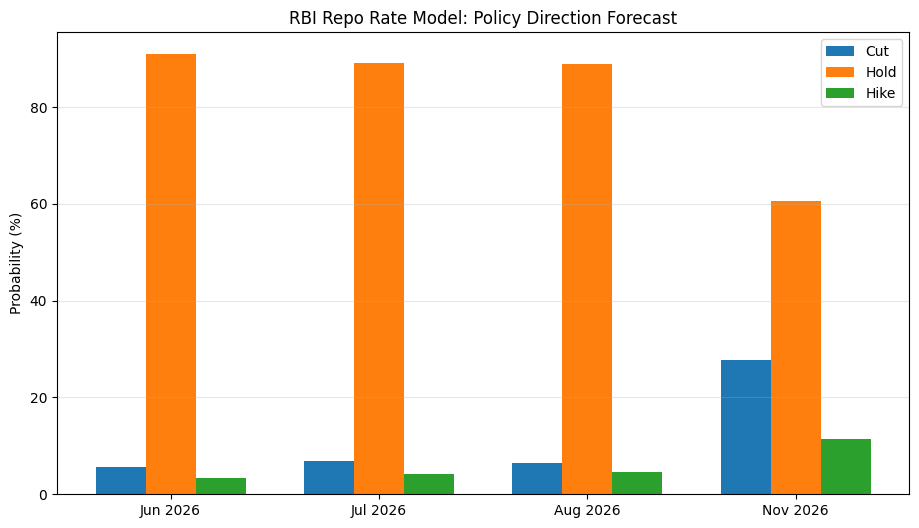

In [29]:
# ============================================================
# 18. SINGLE-PANEL FORECAST PROBABILITY CHART
# ============================================================

plot_df = rbi_forecast_table.copy()

x = np.arange(len(plot_df))
width = 0.24

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    plot_df["Cut probability (%)"],
    width,
    label="Cut"
)

plt.bar(
    x,
    plot_df["Hold probability (%)"],
    width,
    label="Hold"
)

plt.bar(
    x + width,
    plot_df["Hike probability (%)"],
    width,
    label="Hike"
)

plt.xticks(x, plot_df["Forecast end month"])
plt.ylabel("Probability (%)")
plt.title("RBI Repo Rate Model: Policy Direction Forecast")
plt.grid(True, axis="y", alpha=0.30)
plt.legend()
plt.show()

## Final output to review

Run these three lines after the full notebook:

```python
display(robustness_summary)
display(best_by_horizon)
display(forecast_table)
```

Use **Macro F1** and **Balanced Accuracy** to select the best horizon/model. Do not select a model using raw accuracy alone because RBI holds are the most frequent outcome.


## New sun has rised again in this plight

In [30]:
# ============================================================
# CELL 1 — LOAD INDIA-SPECIFIC SUPPLY, ACTIVITY AND CREDIT DATA
# ============================================================

SUPPLY_PATH = "SupplySide.xlsx"

import os
import numpy as np
import pandas as pd

if not os.path.exists(SUPPLY_PATH):
    raise FileNotFoundError(
        f"File not found: {SUPPLY_PATH}\n"
        "Keep SupplySide.xlsx in the same folder as the notebook."
    )

supply_raw = pd.read_excel(SUPPLY_PATH, sheet_name="Sheet1")

# ------------------------------------------------------------
# Standardise column names
# ------------------------------------------------------------

supply_raw = supply_raw.rename(columns={
    "month": "Month",
    "CPI: Food and Non Alcoholic Beverage": "Food_CPI_YoY",
    "Core CPI": "Core_CPI_YoY",
    "Industrial Production Index": "IIP_YoY",
    "MGNREGA: Work Demand: Number of Households": "MGNREGA_Work_Demand",
    "PMI": "PMI",
    "Domestic Credit Growth": "Domestic_Credit_Growth"
})

required_supply_cols = [
    "Month",
    "Food_CPI_YoY",
    "Core_CPI_YoY",
    "IIP_YoY",
    "MGNREGA_Work_Demand",
    "PMI",
    "Domestic_Credit_Growth"
]

missing_cols = [
    col for col in required_supply_cols
    if col not in supply_raw.columns
]

if missing_cols:
    raise ValueError(
        f"These expected columns are missing from SupplySide.xlsx: {missing_cols}"
    )

# ------------------------------------------------------------
# Standardise dates to month-end
# ------------------------------------------------------------

supply_raw["Month"] = (
    pd.to_datetime(supply_raw["Month"], errors="coerce")
    .dt.to_period("M")
    .dt.to_timestamp("M")
)

# Convert all value columns to numeric
value_cols = [
    "Food_CPI_YoY",
    "Core_CPI_YoY",
    "IIP_YoY",
    "MGNREGA_Work_Demand",
    "PMI",
    "Domestic_Credit_Growth"
]

for col in value_cols:
    supply_raw[col] = pd.to_numeric(
        supply_raw[col],
        errors="coerce"
    )

# Keep only Jan-2014 onward, as decided
supply = (
    supply_raw
    .loc[supply_raw["Month"] >= "2014-01-31"]
    .dropna(subset=["Month"])
    .drop_duplicates(subset=["Month"], keep="last")
    .sort_values("Month")
    .reset_index(drop=True)
)

print("Supply-side dataset loaded.")
print(
    "Coverage:",
    supply["Month"].min().date(),
    "to",
    supply["Month"].max().date()
)
print("Rows:", len(supply))

display(
    supply.isna()
    .sum()
    .to_frame("Missing observations")
    .assign(
        Missing_pct=lambda x: (
            100 * x["Missing observations"] / len(supply)
        ).round(1)
    )
)

display(supply.head(12))
display(supply.tail(12))

Supply-side dataset loaded.
Coverage: 2014-01-31 to 2026-05-31
Rows: 149


,Missing observations,Missing_pct
Month,0,0.000
Food_CPI_YoY,0,0.000
Core_CPI_YoY,0,0.000
IIP_YoY,1,0.700
MGNREGA_Work_Demand,3,2.000
PMI,0,0.000
Domestic_Credit_Growth,1,0.700


,Month,Food_CPI_YoY,Core_CPI_YoY,IIP_YoY,MGNREGA_Work_Demand,PMI,Domestic_Credit_Growth
0,2014-01-31,9.659,7.883,4.757,NaN,51.400,14.059
1,2014-02-28,8.161,7.867,5.227,NaN,52.500,13.980
2,2014-03-31,8.606,8.026,2.865,NaN,51.300,13.192
3,2014-04-30,9.192,8.184,3.899,"15,300,862.000",1.300,12.637
4,2014-05-31,8.883,8.412,4.717,"19,590,850.000",51.400,11.310
5,2014-06-30,7.308,6.664,8.292,"23,120,477.000",51.500,10.270
6,2014-07-31,8.718,6.527,5.444,"16,422,016.000",53.000,8.521
7,2014-08-31,8.576,6.022,3.547,"10,024,193.000",52.400,8.401
8,2014-09-30,6.340,5.243,4.257,"8,769,219.000",51.000,8.282
9,2014-10-31,4.326,5.174,0.284,"7,297,404.000",51.600,9.162


,Month,Food_CPI_YoY,Core_CPI_YoY,IIP_YoY,MGNREGA_Work_Demand,PMI,Domestic_Credit_Growth
137,2025-06-30,-0.151,4.414,3.044,"27,562,408.000",58.400,9.261
138,2025-07-31,-0.836,4.123,5.000,"16,579,032.000",59.100,10.388
139,2025-08-31,0.049,4.109,3.633,"11,862,325.000",59.300,10.291
140,2025-09-30,-1.367,4.275,5.530,"11,687,129.000",57.700,10.439
141,2025-10-31,-3.725,4.406,0.000,"11,008,296.000",59.200,11.450
142,2025-11-30,-2.783,4.339,6.470,"12,491,035.000",56.600,10.563
143,2025-12-31,-1.846,4.628,5.797,"15,322,684.000",55.000,12.838
144,2026-01-31,2.120,3.673,4.431,"16,702,167.000",55.400,13.091
145,2026-02-28,3.353,3.703,5.198,"18,697,849.000",56.900,13.825
146,2026-03-31,3.705,3.657,3.239,"14,315,036.000",53.900,14.306


In [31]:
# ============================================================
# CELL 2 — CREATE INDIA-SPECIFIC RBI POLICY FEATURES
# ============================================================

supply_features = supply.copy().sort_values("Month").reset_index(drop=True)

# ------------------------------------------------------------
# 1. Repair only isolated internal gaps
# Do not extrapolate before first or after last actual value.
# ------------------------------------------------------------

repair_cols = [
    "IIP_YoY",
    "MGNREGA_Work_Demand",
    "Domestic_Credit_Growth"
]

supply_features = supply_features.set_index("Month")

supply_features[repair_cols] = (
    supply_features[repair_cols]
    .interpolate(
        method="time",
        limit=2,
        limit_area="inside"
    )
)

supply_features = supply_features.reset_index()

# ------------------------------------------------------------
# 2. Supply-side inflation gap
# Positive gap = food inflation above core inflation.
# This helps distinguish temporary food/supply shocks from
# persistent inflation pressure.
# ------------------------------------------------------------

supply_features["Food_Core_Gap"] = (
    supply_features["Food_CPI_YoY"]
    - supply_features["Core_CPI_YoY"]
)

# ------------------------------------------------------------
# 3. MGNREGA work demand growth
# Positive growth = rising demand for rural employment support,
# often interpreted as rural labour/income stress.
# ------------------------------------------------------------

supply_features["MGNREGA_Demand_YoY"] = (
    supply_features["MGNREGA_Work_Demand"]
    .pct_change(12)
    * 100
)

# ------------------------------------------------------------
# 4. Month-to-month PMI change
# PMI level captures activity; change captures acceleration/
# deceleration in the manufacturing cycle.
# ------------------------------------------------------------

supply_features["PMI_Change_3M"] = (
    supply_features["PMI"]
    - supply_features["PMI"].shift(3)
)

# ------------------------------------------------------------
# 5. Credit growth change
# Level tells broad credit momentum;
# change tells whether financing conditions are strengthening.
# ------------------------------------------------------------

supply_features["Credit_Growth_Change_3M"] = (
    supply_features["Domestic_Credit_Growth"]
    - supply_features["Domestic_Credit_Growth"].shift(3)
)

# ------------------------------------------------------------
# 6. Keep final usable variables only
# ------------------------------------------------------------

SUPPLY_FEATURE_COLUMNS = [
    "Food_CPI_YoY",
    "Core_CPI_YoY",
    "Food_Core_Gap",
    "IIP_YoY",
    "MGNREGA_Demand_YoY",
    "PMI",
    "PMI_Change_3M",
    "Domestic_Credit_Growth",
    "Credit_Growth_Change_3M"
]

print("Feature coverage after transformations:")
display(
    supply_features[
        ["Month"] + SUPPLY_FEATURE_COLUMNS
    ]
    .isna()
    .sum()
    .to_frame("Missing observations")
    .assign(
        Missing_pct=lambda x: (
            100 * x["Missing observations"] / len(supply_features)
        ).round(1)
    )
)

display(
    supply_features[
        ["Month"] + SUPPLY_FEATURE_COLUMNS
    ].head(18)
)

display(
    supply_features[
        ["Month"] + SUPPLY_FEATURE_COLUMNS
    ].tail(12)
)

Feature coverage after transformations:


,Missing observations,Missing_pct
Month,0,0.000
Food_CPI_YoY,0,0.000
Core_CPI_YoY,0,0.000
Food_Core_Gap,0,0.000
IIP_YoY,1,0.700
MGNREGA_Demand_YoY,15,10.100
PMI,0,0.000
PMI_Change_3M,3,2.000
Domestic_Credit_Growth,1,0.700
Credit_Growth_Change_3M,4,2.700


,Month,Food_CPI_YoY,Core_CPI_YoY,Food_Core_Gap,IIP_YoY,MGNREGA_Demand_YoY,PMI,PMI_Change_3M,Domestic_Credit_Growth,Credit_Growth_Change_3M
0,2014-01-31,9.659,7.883,1.776,4.757,NaN,51.400,NaN,14.059,NaN
1,2014-02-28,8.161,7.867,0.295,5.227,NaN,52.500,NaN,13.980,NaN
2,2014-03-31,8.606,8.026,0.581,2.865,NaN,51.300,NaN,13.192,NaN
3,2014-04-30,9.192,8.184,1.008,3.899,NaN,1.300,-50.100,12.637,-1.422
4,2014-05-31,8.883,8.412,0.471,4.717,NaN,51.400,-1.100,11.310,-2.669
5,2014-06-30,7.308,6.664,0.645,8.292,NaN,51.500,0.200,10.270,-2.922
6,2014-07-31,8.718,6.527,2.192,5.444,NaN,53.000,51.700,8.521,-4.117
7,2014-08-31,8.576,6.022,2.554,3.547,NaN,52.400,1.000,8.401,-2.909
8,2014-09-30,6.340,5.243,1.097,4.257,NaN,51.000,-0.500,8.282,-1.988
9,2014-10-31,4.326,5.174,-0.848,0.284,NaN,51.600,-1.400,9.162,0.641


,Month,Food_CPI_YoY,Core_CPI_YoY,Food_Core_Gap,IIP_YoY,MGNREGA_Demand_YoY,PMI,PMI_Change_3M,Domestic_Credit_Growth,Credit_Growth_Change_3M
137,2025-06-30,-0.151,4.414,-4.565,3.044,4.406,58.400,0.300,9.261,-1.861
138,2025-07-31,-0.836,4.123,-4.959,5.000,-12.295,59.100,0.900,10.388,-0.619
139,2025-08-31,0.049,4.109,-4.060,3.633,-26.157,59.300,1.700,10.291,-0.169
140,2025-09-30,-1.367,4.275,-5.642,5.530,-27.060,57.700,-0.700,10.439,1.178
141,2025-10-31,-3.725,4.406,-8.131,0.000,-35.127,59.200,0.100,11.450,1.062
142,2025-11-30,-2.783,4.339,-7.122,6.470,-31.971,56.600,-2.700,10.563,0.271
143,2025-12-31,-1.846,4.628,-6.474,5.797,-28.950,55.000,-2.700,12.838,2.399
144,2026-01-31,2.120,3.673,-1.552,4.431,-25.729,55.400,-3.800,13.091,1.641
145,2026-02-28,3.353,3.703,-0.349,5.198,-14.177,56.900,0.300,13.825,3.263
146,2026-03-31,3.705,3.657,0.048,3.239,-23.200,53.900,-1.100,14.306,1.468


In [32]:
# ============================================================
# CELL 3 — MERGE SUPPLY-SIDE FEATURES WITH RBI POLICY PANEL
# ============================================================

# Start from the already cleaned continuous RBI panel
rbi_v2 = panel_clean.copy().sort_values("Month").reset_index(drop=True)

# Keep only Jan-2014 onward because supply-side data begins there
rbi_v2 = (
    rbi_v2.loc[rbi_v2["Month"] >= "2014-01-31"]
    .copy()
    .reset_index(drop=True)
)

# Merge supply-side / activity data
rbi_v2 = rbi_v2.merge(
    supply_features[
        ["Month"] + SUPPLY_FEATURE_COLUMNS
    ],
    on="Month",
    how="left"
)

print("Merged RBI v2 panel shape:", rbi_v2.shape)
print(
    "Coverage:",
    rbi_v2["Month"].min().date(),
    "to",
    rbi_v2["Month"].max().date()
)

# ------------------------------------------------------------
# Missing-value check after merge
# ------------------------------------------------------------

check_cols = [
    "Repo_rate",
    "CPI_Inflation_YoY",
    "Brent_USD",
    "USDINR",
    "India_VIX",
    "Fed_Funds",
    "Nifty50"
] + SUPPLY_FEATURE_COLUMNS

missing_after_merge = (
    rbi_v2[check_cols]
    .isna()
    .sum()
    .to_frame("Missing observations")
)

missing_after_merge["Missing pct"] = (
    100 * missing_after_merge["Missing observations"] / len(rbi_v2)
).round(1)

display(missing_after_merge)

display(rbi_v2.tail(12))

Merged RBI v2 panel shape: (149, 19)
Coverage: 2014-01-31 to 2026-05-31


,Missing observations,Missing pct
Repo_rate,0,0.000
CPI_Inflation_YoY,0,0.000
Brent_USD,0,0.000
USDINR,0,0.000
India_VIX,0,0.000
Fed_Funds,0,0.000
Nifty50,0,0.000
Food_CPI_YoY,0,0.000
Core_CPI_YoY,0,0.000
Food_Core_Gap,0,0.000


,Month,Repo_rate,CRR,Bank_rate,CPI_Inflation_YoY,Brent_USD,USDINR,India_VIX,Fed_Funds,Nifty50,Food_CPI_YoY,Core_CPI_YoY,Food_Core_Gap,IIP_YoY,MGNREGA_Demand_YoY,PMI,PMI_Change_3M,Domestic_Credit_Growth,Credit_Growth_Change_3M
137,2025-06-30,5.500,4.000,5.750,2.305,68.144,85.455,12.790,4.330,"25,517.051",-0.151,4.414,-4.565,3.044,4.406,58.400,0.300,9.261,-1.861
138,2025-07-31,5.500,4.000,5.750,1.622,72.530,87.715,11.540,4.330,"24,768.350",-0.836,4.123,-4.959,5.000,-12.295,59.100,0.900,10.388,-0.619
139,2025-08-31,5.500,4.000,5.750,2.006,68.120,88.167,11.750,4.330,"24,426.850",0.049,4.109,-4.060,3.633,-26.157,59.300,1.700,10.291,-0.169
140,2025-09-30,5.500,3.750,5.750,1.408,67.020,88.704,11.070,4.220,"24,611.100",-1.367,4.275,-5.642,5.530,-27.060,57.700,-0.700,10.439,1.178
141,2025-10-31,5.500,3.500,5.750,0.039,65.070,88.634,12.150,4.090,"25,722.100",-3.725,4.406,-8.131,0.000,-35.127,59.200,0.100,11.450,1.062
142,2025-11-30,5.500,3.000,5.750,0.493,63.200,89.344,11.620,3.880,"26,202.949",-2.783,4.339,-7.122,6.470,-31.971,56.600,-2.700,10.563,0.271
143,2025-12-31,5.250,3.000,5.500,1.166,60.850,89.769,9.480,3.720,"26,129.600",-1.846,4.628,-6.474,5.797,-28.950,55.000,-2.700,12.838,2.399
144,2026-01-31,5.250,3.000,5.500,2.734,70.690,91.682,13.630,3.640,"25,320.650",2.120,3.673,-1.552,4.431,-25.729,55.400,-3.800,13.091,1.641
145,2026-02-28,5.250,3.000,5.500,3.208,84.319,91.007,13.700,3.640,"25,178.650",3.353,3.703,-0.349,5.198,-14.177,56.900,0.300,13.825,3.263
146,2026-03-31,5.250,3.000,5.500,3.403,99.408,94.356,27.890,3.640,"22,331.400",3.705,3.657,0.048,3.239,-23.200,53.900,-1.100,14.306,1.468


## Build the world now

In [33]:
# ============================================================
# CELL 4 — RBI-SPECIFIC FEATURE ENGINEERING
# ============================================================

model_df_v2 = rbi_v2.copy().sort_values("Month").reset_index(drop=True)

# ------------------------------------------------------------
# 1. Repo-rate movement history
# ------------------------------------------------------------

model_df_v2["repo_change_1m_bp"] = (
    model_df_v2["Repo_rate"].diff() * 100
)

model_df_v2["repo_change_lag1_bp"] = (
    model_df_v2["repo_change_1m_bp"].shift(1)
)

# Real policy stance:
# Positive = repo rate above headline inflation.
model_df_v2["real_repo_lag1"] = (
    model_df_v2["Repo_rate"].shift(1)
    - model_df_v2["CPI_Inflation_YoY"].shift(1)
)

# ------------------------------------------------------------
# 2. Inflation structure
# ------------------------------------------------------------

model_df_v2["core_cpi_yoy_lag1"] = (
    model_df_v2["Core_CPI_YoY"].shift(1)
)

model_df_v2["food_core_gap_lag1"] = (
    model_df_v2["Food_Core_Gap"].shift(1)
)

# ------------------------------------------------------------
# 3. Supply-side and activity conditions
# ------------------------------------------------------------

model_df_v2["iip_yoy_lag1"] = (
    model_df_v2["IIP_YoY"].shift(1)
)

model_df_v2["mgnrega_demand_yoy_lag1"] = (
    model_df_v2["MGNREGA_Demand_YoY"].shift(1)
)

model_df_v2["pmi_lag1"] = (
    model_df_v2["PMI"].shift(1)
)

model_df_v2["credit_growth_lag1"] = (
    model_df_v2["Domestic_Credit_Growth"].shift(1)
)

# ------------------------------------------------------------
# 4. External-price and currency pressure
# ------------------------------------------------------------

model_df_v2["brent_mom_lag1"] = (
    model_df_v2["Brent_USD"].pct_change() * 100
).shift(1)

model_df_v2["usdinr_mom_lag1"] = (
    model_df_v2["USDINR"].pct_change() * 100
).shift(1)

# ------------------------------------------------------------
# 5. Compact RBI-specific final feature set
#
# Keep only one direct activity proxy initially: PMI.
# IIP and MGNREGA will be tested later as alternatives.
# ------------------------------------------------------------

FEATURES_RBI_V2_BASE = [
    "core_cpi_yoy_lag1",
    "food_core_gap_lag1",
    "pmi_lag1",
    "credit_growth_lag1",
    "usdinr_mom_lag1",
    "repo_change_lag1_bp",
    "real_repo_lag1"
]

FEATURES_RBI_V2_IIP = [
    "core_cpi_yoy_lag1",
    "food_core_gap_lag1",
    "iip_yoy_lag1",
    "credit_growth_lag1",
    "usdinr_mom_lag1",
    "repo_change_lag1_bp",
    "real_repo_lag1"
]

FEATURES_RBI_V2_LABOUR = [
    "core_cpi_yoy_lag1",
    "food_core_gap_lag1",
    "mgnrega_demand_yoy_lag1",
    "pmi_lag1",
    "usdinr_mom_lag1",
    "repo_change_lag1_bp",
    "real_repo_lag1"
]

print("Available sample before feature cleaning:", len(model_df_v2))

display(
    model_df_v2[
        [
            "Month",
            "Repo_rate",
            "repo_change_1m_bp"
        ]
        + FEATURES_RBI_V2_BASE
        + [
            "iip_yoy_lag1",
            "mgnrega_demand_yoy_lag1"
        ]
    ].tail(15)
)

Available sample before feature cleaning: 149


,Month,Repo_rate,repo_change_1m_bp,core_cpi_yoy_lag1,food_core_gap_lag1,pmi_lag1,credit_growth_lag1,usdinr_mom_lag1,repo_change_lag1_bp,real_repo_lag1,iip_yoy_lag1,mgnrega_demand_yoy_lag1
134,2025-03-31,6.250,0.000,3.990,-0.154,56.300,10.870,0.785,-25.000,2.757,3.843,2.824
135,2025-04-30,6.000,-25.000,4.102,-1.217,58.100,11.122,-2.048,0.000,2.685,6.655,2.276
136,2025-05-31,6.000,0.000,4.108,-1.971,58.200,11.006,-0.430,-25.000,2.663,5.784,-6.498
137,2025-06-30,5.500,-50.000,4.238,-2.737,57.600,10.461,0.405,0.000,2.967,4.720,4.442
138,2025-07-31,5.500,0.000,4.414,-4.565,58.400,9.261,-0.071,-50.000,3.195,3.044,4.406
139,2025-08-31,5.500,0.000,4.123,-4.959,59.100,10.388,2.644,0.000,3.878,5.000,-12.295
140,2025-09-30,5.500,0.000,4.109,-4.060,59.300,10.291,0.516,0.000,3.494,3.633,-26.157
141,2025-10-31,5.500,0.000,4.275,-5.642,57.700,10.439,0.610,0.000,4.092,5.530,-27.060
142,2025-11-30,5.500,0.000,4.406,-8.131,59.200,11.450,-0.079,0.000,5.461,0.000,-35.127
143,2025-12-31,5.250,-25.000,4.339,-7.122,56.600,10.563,0.800,0.000,5.007,6.470,-31.971


In [34]:
# ============================================================
# CELL 5 — COMPARE RBI V2 FEATURE SETS AT THE 2-MONTH HORIZON
#
# We start with 2 months because it was the strongest horizon
# in the earlier RBI model.
# ============================================================

# ------------------------------------------------------------
# 1. Create a clean target-ready sample
# ------------------------------------------------------------

COMPARISON_HORIZON = 2
MIN_TRAIN_MONTHS = 84

feature_sets = {
    "Base: PMI + Credit": FEATURES_RBI_V2_BASE,
    "Activity: IIP + Credit": FEATURES_RBI_V2_IIP,
    "Labour: MGNREGA + PMI": FEATURES_RBI_V2_LABOUR
}

comparison_rows = []
comparison_backtests = {}

for model_name, features in feature_sets.items():

    # Keep only rows with all selected features available
    sample = (
        model_df_v2
        .dropna(subset=features)
        .copy()
        .sort_values("Month")
        .reset_index(drop=True)
    )

    print(f"\nRunning: {model_name}")
    print(
        "Sample:",
        sample["Month"].min().date(),
        "to",
        sample["Month"].max().date(),
        "| observations:",
        len(sample)
    )

    # Use the same expanding-window function already defined
    bt = expanding_window_backtest(
        data=sample,
        horizon_months=COMPARISON_HORIZON,
        features=features,
        min_train_months=MIN_TRAIN_MONTHS
    )

    comparison_backtests[model_name] = bt

    if bt.empty:
        print("No usable backtest produced.")
        continue

    actual = bt["Actual direction"]

    # Logit-only result
    comparison_rows.append({
        "Feature set": model_name,
        "Model": "Logit + Ridge",
        "Sample observations": len(sample),
        "Backtest observations": len(bt),
        "Direction accuracy": accuracy_score(
            actual,
            bt["Logit call"]
        ),
        "Balanced accuracy": balanced_accuracy_score(
            actual,
            bt["Logit call"]
        ),
        "Macro F1": f1_score(
            actual,
            bt["Logit call"],
            average="macro",
            zero_division=0
        ),
        "BP MAE": mean_absolute_error(
            bt["Actual change bp"],
            bt["Ridge forecast bp"]
        ),
        "BP RMSE": np.sqrt(
            mean_squared_error(
                bt["Actual change bp"],
                bt["Ridge forecast bp"]
            )
        )
    })

    # Random Forest robustness result
    comparison_rows.append({
        "Feature set": model_name,
        "Model": "Random Forest",
        "Sample observations": len(sample),
        "Backtest observations": len(bt),
        "Direction accuracy": accuracy_score(
            actual,
            bt["RF call"]
        ),
        "Balanced accuracy": balanced_accuracy_score(
            actual,
            bt["RF call"]
        ),
        "Macro F1": f1_score(
            actual,
            bt["RF call"],
            average="macro",
            zero_division=0
        ),
        "BP MAE": mean_absolute_error(
            bt["Actual change bp"],
            bt["RF forecast bp"]
        ),
        "BP RMSE": np.sqrt(
            mean_squared_error(
                bt["Actual change bp"],
                bt["RF forecast bp"]
            )
        )
    })

    # Ensemble robustness result
    comparison_rows.append({
        "Feature set": model_name,
        "Model": "50:50 Ensemble",
        "Sample observations": len(sample),
        "Backtest observations": len(bt),
        "Direction accuracy": accuracy_score(
            actual,
            bt["Ensemble call"]
        ),
        "Balanced accuracy": balanced_accuracy_score(
            actual,
            bt["Ensemble call"]
        ),
        "Macro F1": f1_score(
            actual,
            bt["Ensemble call"],
            average="macro",
            zero_division=0
        ),
        "BP MAE": mean_absolute_error(
            bt["Actual change bp"],
            bt["Ensemble forecast bp"]
        ),
        "BP RMSE": np.sqrt(
            mean_squared_error(
                bt["Actual change bp"],
                bt["Ensemble forecast bp"]
            )
        )
    })

feature_set_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        ["Macro F1", "Balanced accuracy", "BP MAE"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

display(feature_set_comparison)


Running: Base: PMI + Credit
Sample: 2014-03-31 to 2026-05-31 | observations: 147

Running: Activity: IIP + Credit
Sample: 2014-03-31 to 2026-05-31 | observations: 147

Running: Labour: MGNREGA + PMI
Sample: 2015-05-31 to 2026-05-31 | observations: 133


,Feature set,Model,Sample observations,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE,BP RMSE
0,Activity: IIP + Credit,Logit + Ridge,147,61,0.672,0.496,0.509,16.361,23.258
1,Labour: MGNREGA + PMI,Logit + Ridge,133,47,0.638,0.477,0.498,17.107,21.631
2,Base: PMI + Credit,Logit + Ridge,147,61,0.639,0.481,0.489,15.693,23.404
3,Base: PMI + Credit,50:50 Ensemble,147,61,0.689,0.487,0.478,15.453,23.484
4,Labour: MGNREGA + PMI,50:50 Ensemble,133,47,0.596,0.394,0.395,16.692,21.955
5,Activity: IIP + Credit,50:50 Ensemble,147,61,0.672,0.420,0.389,15.636,23.412
6,Labour: MGNREGA + PMI,Random Forest,133,47,0.574,0.352,0.352,16.276,22.779
7,Activity: IIP + Credit,Random Forest,147,61,0.656,0.378,0.350,15.357,24.029
8,Base: PMI + Credit,Random Forest,147,61,0.639,0.370,0.340,15.418,23.893


In [35]:
CANDIDATE_ADDITIONS = [
    "food_core_gap_lag1",
    "iip_yoy_lag1",
    "credit_growth_lag1"
]

In [36]:
# ============================================================
# CELL 6 — HYBRID FEATURE TEST AGAINST ORIGINAL RBI MODEL
#
# Objective:
# Keep the original model intact and add one India-specific
# variable at a time. This avoids throwing away useful signals.
# ============================================================

COMPARISON_HORIZON = 2
MIN_TRAIN_MONTHS = 84

# Original compact feature set that previously performed best.
FEATURES_ORIGINAL_RBI = [
    "cpi_yoy_lag1",
    "brent_mom_lag1",
    "usdinr_mom_lag1",
    "india_vix_lag1",
    "fed_funds_change_lag1",
    "nifty50_mom_lag1",
    "repo_change_lag1_bp",
    "real_repo_lag1"
]

# These columns already exist in model_df_v2 / rbi_v2,
# but create the original lagged features again here so the
# comparison is fully self-contained.

hybrid_df = model_df_v2.copy().sort_values("Month").reset_index(drop=True)

hybrid_df["cpi_yoy_lag1"] = hybrid_df["CPI_Inflation_YoY"].shift(1)

hybrid_df["india_vix_lag1"] = hybrid_df["India_VIX"].shift(1)

hybrid_df["fed_funds_change_lag1"] = (
    hybrid_df["Fed_Funds"].diff().shift(1)
)

hybrid_df["nifty50_mom_lag1"] = (
    hybrid_df["Nifty50"].pct_change() * 100
).shift(1)

# These should already exist from Cell 4, but this safeguards
# against running cells out of order.
hybrid_df["brent_mom_lag1"] = (
    hybrid_df["Brent_USD"].pct_change() * 100
).shift(1)

hybrid_df["usdinr_mom_lag1"] = (
    hybrid_df["USDINR"].pct_change() * 100
).shift(1)

hybrid_df["repo_change_1m_bp"] = (
    hybrid_df["Repo_rate"].diff() * 100
)

hybrid_df["repo_change_lag1_bp"] = (
    hybrid_df["repo_change_1m_bp"].shift(1)
)

hybrid_df["real_repo_lag1"] = (
    hybrid_df["Repo_rate"].shift(1)
    - hybrid_df["CPI_Inflation_YoY"].shift(1)
)

# ------------------------------------------------------------
# Candidate hybrid specifications
# ------------------------------------------------------------

hybrid_feature_sets = {
    "Original compact model": FEATURES_ORIGINAL_RBI,

    "Original + Food-Core Gap": (
        FEATURES_ORIGINAL_RBI
        + ["food_core_gap_lag1"]
    ),

    "Original + IIP Growth": (
        FEATURES_ORIGINAL_RBI
        + ["iip_yoy_lag1"]
    ),

    "Original + Credit Growth": (
        FEATURES_ORIGINAL_RBI
        + ["credit_growth_lag1"]
    )
}

hybrid_results = []

for name, features in hybrid_feature_sets.items():

    sample = (
        hybrid_df
        .dropna(subset=features)
        .copy()
        .sort_values("Month")
        .reset_index(drop=True)
    )

    bt = expanding_window_backtest(
        data=sample,
        horizon_months=COMPARISON_HORIZON,
        features=features,
        min_train_months=MIN_TRAIN_MONTHS
    )

    if bt.empty:
        print(f"No usable backtest for: {name}")
        continue

    actual = bt["Actual direction"]

    hybrid_results.append({
        "Feature set": name,
        "Sample observations": len(sample),
        "Backtest observations": len(bt),

        "Direction accuracy": accuracy_score(
            actual,
            bt["Logit call"]
        ),

        "Balanced accuracy": balanced_accuracy_score(
            actual,
            bt["Logit call"]
        ),

        "Macro F1": f1_score(
            actual,
            bt["Logit call"],
            average="macro",
            zero_division=0
        ),

        "BP MAE": mean_absolute_error(
            bt["Actual change bp"],
            bt["Ridge forecast bp"]
        ),

        "BP RMSE": np.sqrt(
            mean_squared_error(
                bt["Actual change bp"],
                bt["Ridge forecast bp"]
            )
        )
    })

hybrid_comparison = (
    pd.DataFrame(hybrid_results)
    .sort_values(
        ["Macro F1", "Balanced accuracy", "BP MAE"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

display(hybrid_comparison)

,Feature set,Sample observations,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE,BP RMSE
0,Original + Credit Growth,147,61,0.787,0.687,0.696,14.339,22.143
1,Original + IIP Growth,147,61,0.770,0.679,0.682,14.261,22.162
2,Original compact model,147,61,0.770,0.679,0.682,14.298,22.093
3,Original + Food-Core Gap,147,61,0.738,0.630,0.635,14.821,21.889


In [37]:
FEATURES_RBI_FINAL = [
    "cpi_yoy_lag1",
    "brent_mom_lag1",
    "usdinr_mom_lag1",
    "india_vix_lag1",
    "fed_funds_change_lag1",
    "nifty50_mom_lag1",
    "repo_change_lag1_bp",
    "real_repo_lag1",
    "credit_growth_lag1"
]

In [38]:
# ============================================================
# CELL 7 — FINAL RBI MODEL: ORIGINAL FEATURES + CREDIT GROWTH
# ============================================================

FEATURES_RBI_FINAL = [
    "cpi_yoy_lag1",
    "brent_mom_lag1",
    "usdinr_mom_lag1",
    "india_vix_lag1",
    "fed_funds_change_lag1",
    "nifty50_mom_lag1",
    "repo_change_lag1_bp",
    "real_repo_lag1",
    "credit_growth_lag1"
]

# Use the same hybrid dataframe that already contains both
# original variables and India-specific additions.
final_rbi_df = (
    hybrid_df
    .dropna(subset=FEATURES_RBI_FINAL)
    .copy()
    .sort_values("Month")
    .reset_index(drop=True)
)

print("Final RBI model sample:")
print(
    final_rbi_df["Month"].min().date(),
    "to",
    final_rbi_df["Month"].max().date()
)
print("Observations:", len(final_rbi_df))

final_rbi_rows = []
final_rbi_backtests = {}

for h in HORIZONS:
    print(f"\nRunning final RBI model for {h}-month horizon...")

    bt = expanding_window_backtest(
        data=final_rbi_df,
        horizon_months=h,
        features=FEATURES_RBI_FINAL,
        min_train_months=MIN_TRAIN_MONTHS
    )

    final_rbi_backtests[h] = bt

    if bt.empty:
        print("No usable backtest.")
        continue

    actual = bt["Actual direction"]

    for model_name, call_col, bp_col in [
        ("Logit + Ridge", "Logit call", "Ridge forecast bp"),
        ("Random Forest", "RF call", "RF forecast bp"),
        ("50:50 Ensemble", "Ensemble call", "Ensemble forecast bp")
    ]:
        final_rbi_rows.append({
            "Horizon": f"{h} month(s)",
            "Model": model_name,
            "Backtest observations": len(bt),

            "Direction accuracy": accuracy_score(
                actual,
                bt[call_col]
            ),

            "Balanced accuracy": balanced_accuracy_score(
                actual,
                bt[call_col]
            ),

            "Macro F1": f1_score(
                actual,
                bt[call_col],
                average="macro",
                zero_division=0
            ),

            "BP MAE": mean_absolute_error(
                bt["Actual change bp"],
                bt[bp_col]
            ),

            "BP RMSE": np.sqrt(
                mean_squared_error(
                    bt["Actual change bp"],
                    bt[bp_col]
                )
            )
        })

final_rbi_summary = (
    pd.DataFrame(final_rbi_rows)
    .sort_values(
        ["Horizon", "Macro F1", "Balanced accuracy"],
        ascending=[True, False, False]
    )
    .reset_index(drop=True)
)

display(final_rbi_summary)

Final RBI model sample:
2014-03-31 to 2026-05-31
Observations: 147

Running final RBI model for 1-month horizon...

Running final RBI model for 2-month horizon...

Running final RBI model for 3-month horizon...

Running final RBI model for 6-month horizon...


,Horizon,Model,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE,BP RMSE
0,1 month(s),Logit + Ridge,62,0.790,0.363,0.360,8.809,14.289
1,1 month(s),Random Forest,62,0.839,0.333,0.304,8.854,14.839
2,1 month(s),50:50 Ensemble,62,0.806,0.321,0.298,8.809,14.447
3,2 month(s),Logit + Ridge,61,0.787,0.687,0.696,14.339,22.143
4,2 month(s),50:50 Ensemble,61,0.705,0.537,0.558,14.679,22.643
5,2 month(s),Random Forest,61,0.639,0.396,0.394,15.462,23.797
6,3 month(s),Logit + Ridge,60,0.700,0.624,0.641,20.064,29.672
7,3 month(s),50:50 Ensemble,60,0.700,0.624,0.641,20.445,30.848
8,3 month(s),Random Forest,60,0.600,0.496,0.493,22.390,33.268
9,6 month(s),Logit + Ridge,57,0.754,0.764,0.749,37.881,53.163


In [39]:
# ============================================================
# CELL 8 — FINAL RBI REPO-RATE FORECAST
# Final model: Logit + Ridge
# ============================================================

final_models_rbi = {}

for h in HORIZONS:

    horizon_df = create_policy_targets(
        data=final_rbi_df,
        horizon_months=h
    ).copy()

    change_col = f"target_change_{h}m_bp"
    direction_col = f"target_direction_{h}m"

    train_df = (
        horizon_df
        .dropna(subset=[change_col, direction_col])
        .copy()
        .sort_values("Month")
        .reset_index(drop=True)
    )

    X_train = train_df[FEATURES_RBI_FINAL]
    y_direction = train_df[direction_col]
    y_change_bp = train_df[change_col]

    logit_model = build_logit_classifier()
    ridge_model = build_ridge_regressor()

    logit_model.fit(X_train, y_direction)
    ridge_model.fit(X_train, y_change_bp)

    final_models_rbi[h] = {
        "logit": logit_model,
        "ridge": ridge_model,
        "training_rows": len(train_df)
    }

print("Final RBI Logit + Ridge models trained.")

Final RBI Logit + Ridge models trained.


In [40]:
# ============================================================
# CELL 9 — CURRENT POLICY FORECAST TABLE
# ============================================================

latest_row = (
    final_rbi_df
    .sort_values("Month")
    .iloc[[-1]]
    .copy()
)

forecast_origin = latest_row["Month"].iloc[0]
current_repo_rate = float(latest_row["Repo_rate"].iloc[0])

forecast_rows = []

for h in HORIZONS:

    logit_model = final_models_rbi[h]["logit"]
    ridge_model = final_models_rbi[h]["ridge"]

    X_latest = latest_row[FEATURES_RBI_FINAL]

    probs = aligned_probabilities(logit_model, X_latest)

    policy_call = POLICY_CLASSES[np.argmax(probs)]

    probability_implied_bp = float(
        np.dot(
            probs,
            [-MOVE_STEP_BP, 0, MOVE_STEP_BP]
        )
    )

    ridge_bp = float(ridge_model.predict(X_latest)[0])

    forecast_end = (
        forecast_origin + pd.DateOffset(months=h)
    )

    forecast_rows.append({
        "Forecast origin": forecast_origin.strftime("%Y-%m-%d"),
        "Forecast end month": forecast_end.strftime("%b %Y"),
        "Horizon": f"{h} month(s)",

        "Policy call": policy_call,

        "Cut probability (%)": round(probs[0] * 100, 1),
        "Hold probability (%)": round(probs[1] * 100, 1),
        "Hike probability (%)": round(probs[2] * 100, 1),

        "Probability-implied change (bp)": round(
            probability_implied_bp, 1
        ),

        "Ridge expected change (bp)": round(
            ridge_bp, 1
        ),

        "Current repo rate (%)": round(
            current_repo_rate, 2
        ),

        "Probability-implied repo rate (%)": round(
            current_repo_rate + probability_implied_bp / 100, 2
        ),

        "Ridge-implied repo rate (%)": round(
            current_repo_rate + ridge_bp / 100, 2
        ),

        "Training observations": final_models_rbi[h]["training_rows"]
    })

rbi_final_forecast = pd.DataFrame(forecast_rows)

display(rbi_final_forecast)

,Forecast origin,Forecast end month,Horizon,Policy call,Cut probability (%),Hold probability (%),Hike probability (%),Probability-implied change (bp),Ridge expected change (bp),Current repo rate (%),Probability-implied repo rate (%),Ridge-implied repo rate (%),Training observations
0,2026-05-31,Jun 2026,1 month(s),Hold,4.800,92.600,2.600,-0.600,1.000,5.250,5.240,5.260,146
1,2026-05-31,Jul 2026,2 month(s),Hold,5.000,92.500,2.400,-0.700,2.700,5.250,5.240,5.280,145
2,2026-05-31,Aug 2026,3 month(s),Hold,3.500,95.100,1.400,-0.500,3.500,5.250,5.240,5.290,144
3,2026-05-31,Nov 2026,6 month(s),Hold,11.600,86.900,1.500,-2.500,-11.400,5.250,5.220,5.140,141
